# OHLC PLOT (Open–High–Low–Close)

✔ Basic OHLC (matplotlib)

✔ OHLC using mplfinance

✔ OHLC with Volume

✔ OHLC with Moving Averages

✔ OHLC with Trendlines

✔ OHLC with Bollinger Bands

✔ OHLC + RSI/MACD

✔ OHLC with custom colors

✔ OHLC multi-subplot layout

✔ OHLC interactive (Plotly)

✔ OHLC with Heikin-Ashi equivalent (optional)

## Generate Sample Data (Used for All Examples)

In [2]:
import pandas as pd
import numpy as np

np.random.seed(42)
dates = pd.date_range("2024-01-01", periods=60)

price = np.cumsum(np.random.randn(60)) + 100

df = pd.DataFrame({
    'Open':  price + np.random.uniform(-1, 1, 60),
    'High':  price + np.random.uniform(0, 2, 60),
    'Low':   price - np.random.uniform(0, 2, 60),
    'Close': price + np.random.uniform(-1, 1, 60),
    'Volume': np.random.randint(100000, 300000, 60)
}, index=dates)


## Basic OHLC — Matplotlib (raw manual version)

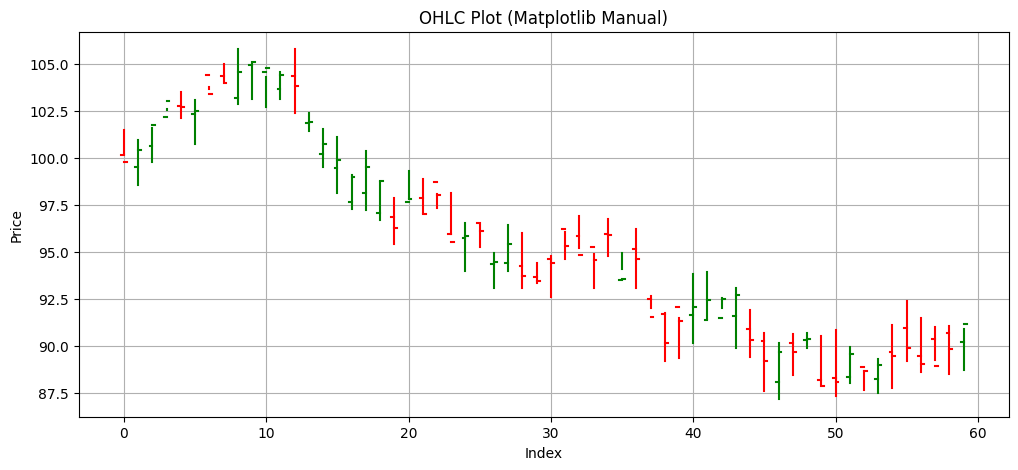

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

for i, (idx, row) in enumerate(df.iterrows()):
    color = 'green' if row['Close'] > row['Open'] else 'red'

    # High–Low line
    plt.plot([i, i], [row['Low'], row['High']], color=color)

    # Open tick (left)
    plt.plot([i-0.2, i], [row['Open'], row['Open']], color=color)

    # Close tick (right)
    plt.plot([i, i+0.2], [row['Close'], row['Close']], color=color)

plt.title("OHLC Plot (Matplotlib Manual)")
plt.xlabel("Index")
plt.ylabel("Price")
plt.grid(True)
plt.show()


## OHLC Using mplfinance

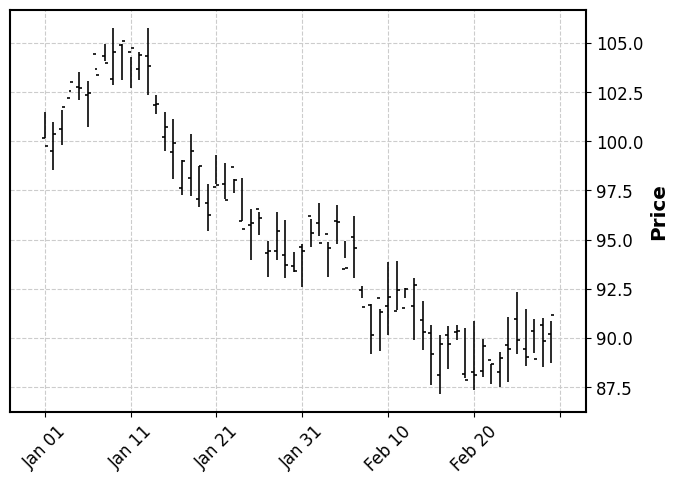

In [4]:
import mplfinance as mpf

mpf.plot(df, type='ohlc', style='classic')


## OHLC + Volume

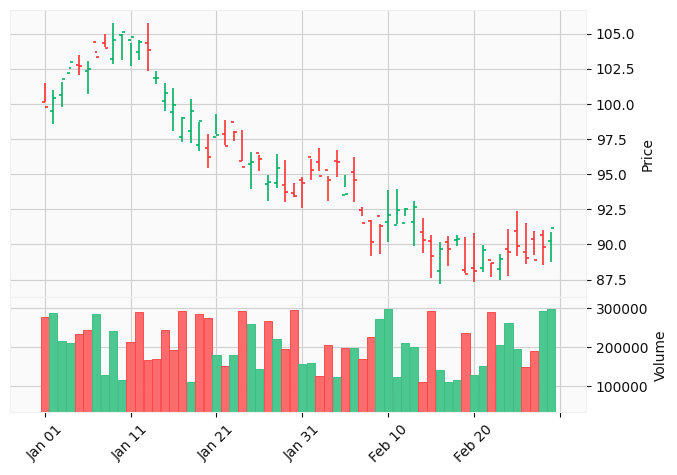

In [6]:
mpf.plot(df, type='ohlc', volume=True, style='yahoo')


## OHLC + Moving Averages

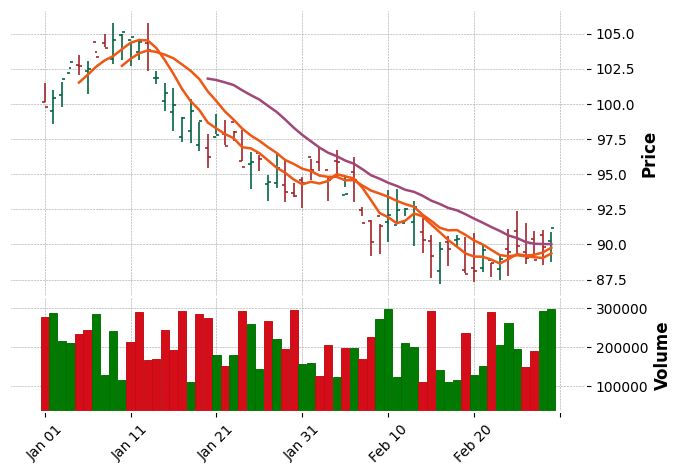

In [8]:
mpf.plot(
    df,
    type='ohlc',
    mav=(5, 10, 20),
    volume=True,
    style='charles'
)


## OHLC + Bollinger Bands

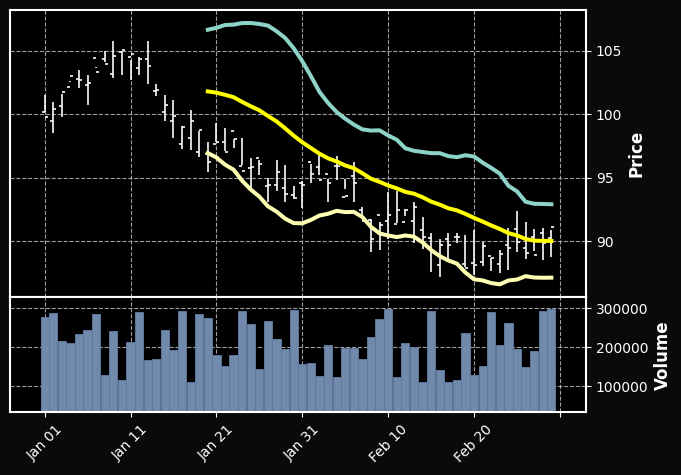

In [10]:
df['MA20'] = df['Close'].rolling(20).mean()
df['BB_up'] = df['MA20'] + 2*df['Close'].rolling(20).std()
df['BB_dn'] = df['MA20'] - 2*df['Close'].rolling(20).std()

ap = [
    mpf.make_addplot(df['MA20'], color='yellow'),
    mpf.make_addplot(df['BB_up']),
    mpf.make_addplot(df['BB_dn'])
]

mpf.plot(df, type='ohlc', addplot=ap, volume=True, style='mike')


## OHLC + Trendlines

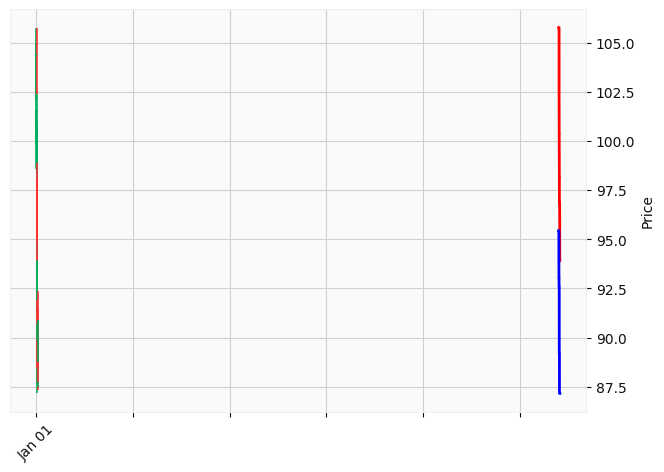

In [12]:
import matplotlib.pyplot as plt
fig, ax = mpf.plot(df, type='ohlc', returnfig=True, style='yahoo')

ax[0].plot(df.index, df['High'].rolling(20).max(), color='red', linewidth=2)
ax[0].plot(df.index, df['Low'].rolling(20).min(), color='blue', linewidth=2)

plt.show()


## OHLC + RSI (extra panel)

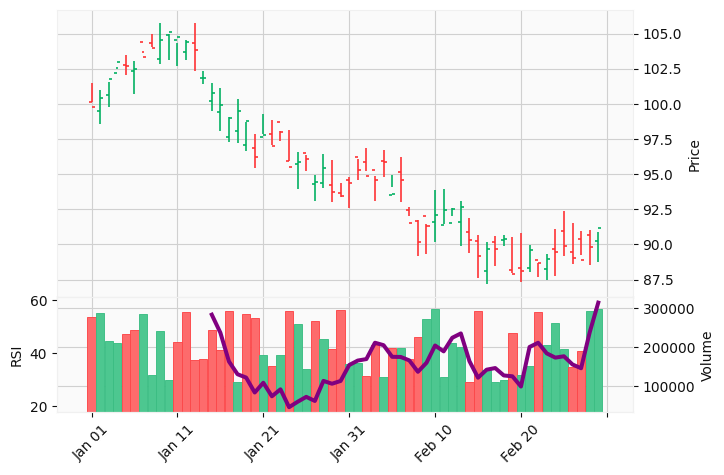

In [13]:
def compute_rsi(s, period=14):
    diff = s.diff()
    up = diff.clip(lower=0).rolling(period).mean()
    down = -diff.clip(upper=0).rolling(period).mean()
    rs = up / down
    return 100 - (100 / (1 + rs))

df['RSI'] = compute_rsi(df['Close'])

ap = [mpf.make_addplot(df['RSI'], panel=1, ylabel='RSI', color='purple')]

mpf.plot(df, type='ohlc', volume=True, addplot=ap, style='yahoo')


## OHLC + MACD Panel

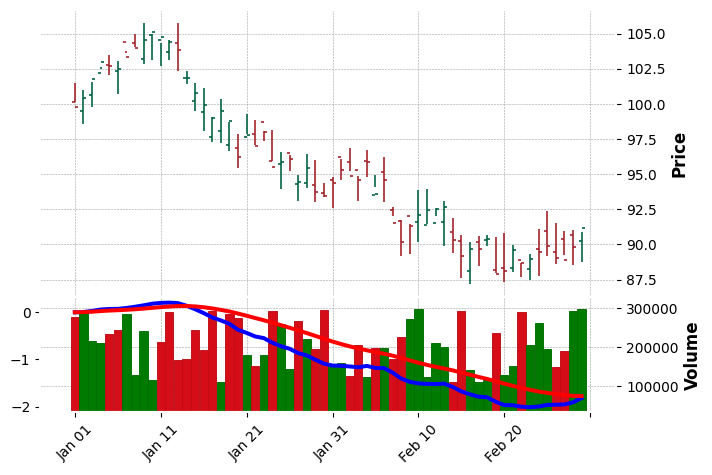

In [15]:
df['EMA12'] = df['Close'].ewm(12).mean()
df['EMA26'] = df['Close'].ewm(26).mean()
df['MACD'] = df['EMA12'] - df['EMA26']
df['Signal'] = df['MACD'].ewm(9).mean()

ap = [
    mpf.make_addplot(df['MACD'], panel=1, color='blue'),
    mpf.make_addplot(df['Signal'], panel=1, color='red')
]

mpf.plot(df, type='ohlc', volume=True, addplot=ap, style='charles')


## OHLC + Custom Colors

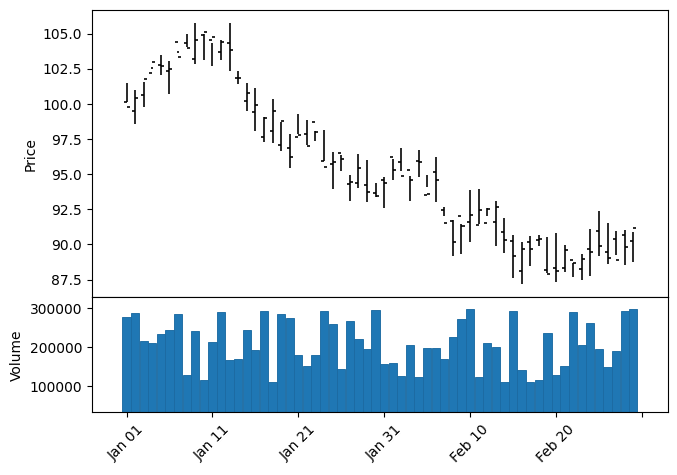

In [16]:
custom_style = mpf.make_mpf_style(
    marketcolors=mpf.make_marketcolors(
        up='green', down='red', wick='black', edge='black'
    )
)

mpf.plot(df, type='ohlc', volume=True, style=custom_style)


## Multi-subplot OHLC Layout

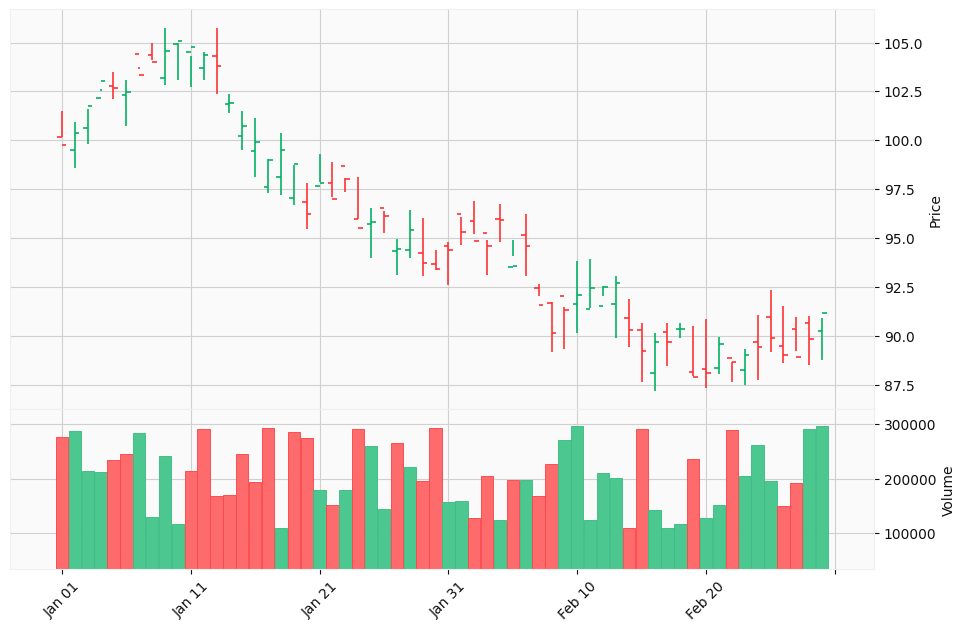

In [17]:
fig = mpf.plot(
    df,
    type='ohlc',
    volume=True,
    returnfig=True,
    style='yahoo',
    figsize=(12,8)
)


## Interactive OHLC (Plotly)

In [18]:
import plotly.graph_objects as go

fig = go.Figure(
    data=[go.Ohlc(
        x=df.index,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close']
    )]
)

fig.update_layout(title="Interactive OHLC Chart")
fig.show()


## OHLC + Volume (Plotly)

In [19]:
fig = go.Figure()

fig.add_trace(go.Ohlc(
    x=df.index,
    open=df["Open"], high=df["High"],
    low=df["Low"], close=df["Close"]
))

fig.add_trace(go.Bar(
    x=df.index, y=df["Volume"],
    marker_color="lightblue", yaxis="y2"
))

fig.update_layout(
    yaxis2=dict(overlaying="y", side="right", range=[0, df["Volume"].max()*4]),
    title="OHLC with Volume"
)

fig.show()


## OHLC with Filled Area Trend (Hybrid Plot)

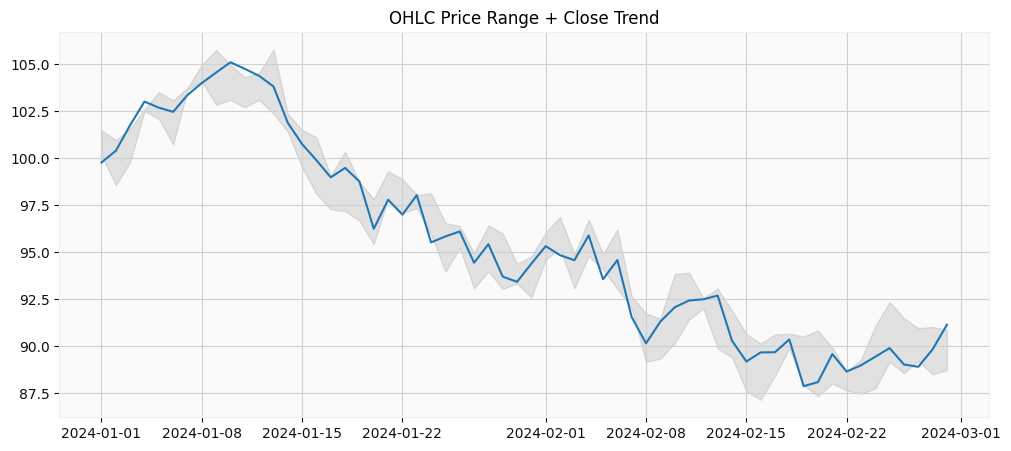

In [20]:
plt.figure(figsize=(12,5))
plt.fill_between(df.index, df['Low'], df['High'], color='gray', alpha=0.2)
plt.plot(df.index, df['Close'], linewidth=1.5)
plt.title("OHLC Price Range + Close Trend")
plt.grid(True)
plt.show()


## OHLC + Highlight Min/Max Days

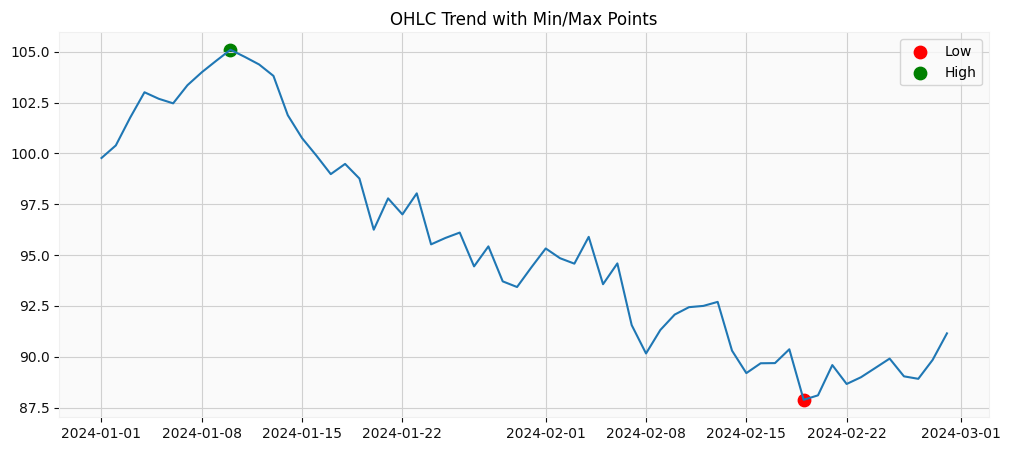

In [21]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Close'])

min_day = df['Close'].idxmin()
max_day = df['Close'].idxmax()

plt.scatter(min_day, df['Close'].min(), color='red', s=80, label='Low')
plt.scatter(max_day, df['Close'].max(), color='green', s=80, label='High')

plt.title("OHLC Trend with Min/Max Points")
plt.legend()
plt.show()
